In [ ]:
# !pip install google-cloud-aiplatform

In [ ]:
# !pip install utils
# !pip install matplotlib
# !pip install scikit-learn
# !pip install seaborn
# !pip install mplcursors
# !conda install scann


3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: failed



PackagesNotFoundError: The following packages are not available from current channels:

  - scann

Current channels:

  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [50]:
from google.auth.transport.requests import Request
from google.oauth2.service_account import Credentials

In [51]:
key_path = r"D:\LLM-Learning-Journey\starry-compiler-492313-m3-dd4add6d71ce.json"

In [52]:
credentials = Credentials.from_service_account_file(
    key_path,
    scopes=['https://www.googleapis.com/auth/cloud-platform'])

if credentials.expired:
    credentials.refresh(Request())
    print("Credentials are valid and ready to use.")
else:
    print("Credentials are valid and ready to use.")

Credentials are valid and ready to use.


In [53]:
PROJECT_ID = "starry-compiler-492313-m3"
REGION = 'us-central1'
import vertexai
vertexai.init(project=PROJECT_ID, location=REGION, credentials=credentials)

In [54]:
from vertexai.language_models import TextEmbeddingModel

In [55]:
embedding_model = TextEmbeddingModel.from_pretrained("text-embedding-004")

d:\LLM-Learning-Journey\LLM-Learning-Journey\.venv\Lib\site-packages\vertexai\_model_garden\_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [9]:
embedding = embedding_model.get_embeddings(["Life"])

In [10]:
vector = embedding[0].values   
print(vector[:10])
print("length of the vector:", len(vector))

[-0.014105577021837234, -0.00730274710804224, -0.01759343035519123, 0.001341084367595613, -0.07463667541742325, 0.040915317833423615, -0.005673747975379229, 0.037596337497234344, 0.01530362293124199, 0.053805943578481674]
length of the vector: 768


In [11]:
embedding = embedding_model.get_embeddings(["What is the meaning of life?"])

In [12]:
vector = embedding[0].values
print(vector[:10])
print("length of the vector:", len(vector))

[-0.010626512579619884, 0.019580397754907608, 0.020961495116353035, 0.0007800217717885971, -0.06189257651567459, 0.014572087675333023, -0.0022393004037439823, 0.013389108702540398, 0.014531472697854042, 0.022664014250040054]
length of the vector: 768


In [17]:
sent1 = "The sales drop in this quarter when compared to the last quarter" 
sent2 = "The Fall of the sales in this quarter is higher than the last quarter"
sent3  = "sales team are doing a bad job in this quarter"

In [18]:
emb1 = embedding_model.get_embeddings([sent1])[0].values
emb2 = embedding_model.get_embeddings([sent2])[0].values
emb3 = embedding_model.get_embeddings([sent3])[0].values

In [19]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
print(f"cosine_similarity([emb1], [emb2]): {cosine_similarity([emb1], [emb2])}")
print(f"cosine_similarity([emb1], [emb3]): {cosine_similarity([emb1], [emb3])}")
print(f"cosine_similarity([emb2], [emb3]): {cosine_similarity([emb2], [emb3])}")

cosine_similarity([emb1], [emb2]): [[0.93761147]]
cosine_similarity([emb1], [emb3]): [[0.75722654]]
cosine_similarity([emb2], [emb3]): [[0.74181164]]


In [ ]:
sent1 = "The Kids are playing in the park area"
sent2 = "The playing area in the park are for kids "

sent1_imp_word_arr = ["Kids", "playing", "park", "area"]
sent2_imp_word_arr = ["playing", "area", "park", "Kids"] 

emb_imp1 = [emb.values for emb in embedding_model.get_embeddings(sent1_imp_word_arr)]
emb_imp1_arr = np.stack(emb_imp1)
emb_imp2 = [emb.values for emb in embedding_model.get_embeddings(sent2_imp_word_arr)]
emb_imp2_arr = np.stack(emb_imp2)
emb_imp1_mean = emb_imp1_arr.mean(axis=0)
emb_imp2_mean = emb_imp2_arr.mean(axis=0)
emb_imp1_mean ==  emb_imp2_mean
print(f"cosine_similarity([emb_imp1_mean], [emb_imp2_mean]): {cosine_similarity([emb_imp1_mean], [emb_imp2_mean])}")

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [59]:
emb_sent1 = embedding_model.get_embeddings([sent1])[0].values  
emb_sent2 = embedding_model.get_embeddings([sent2])[0].values
emb_sent1[:10 ], emb_sent2[:10]
print(f"cosine_similarity([emb_sent1], [emb_sent2]): {cosine_similarity([emb_sent1], [emb_sent2])}")

cosine_similarity([emb_sent1], [emb_sent2]): [[0.7982165]]


### Visualisation of the embedding

### PCA

In [64]:
sent_v1 = "There are lot of animals in the zoo"
sent_v2 = "Each animal in the zoo has a different story to tell"
sent_v3 = "In forest you can find many animals true nature"
sent_v4 = "The Forest is the place where you can find the different plant species"
sent_v5 = "There are a lot people work in the office"
sent_v6 = "office is the place where people work and do their job"
sentences = [sent_v1, sent_v2, sent_v3, sent_v4, sent_v5, sent_v6]
embeddings = [embedding_model.get_embeddings([sent])[0].values for sent in sentences]
embeddings_arr = np.stack(embeddings)


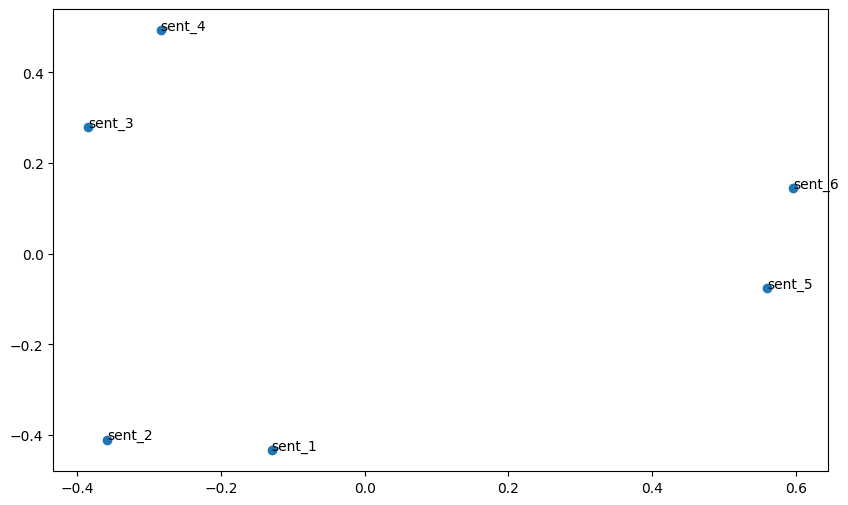

In [65]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_arr)
plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
for i, sent in enumerate(sentences):
    plt.annotate(f"sent_{i+1}", (embeddings_2d[i, 0], embeddings_2d[i, 1]))
plt.show()

### Heat map

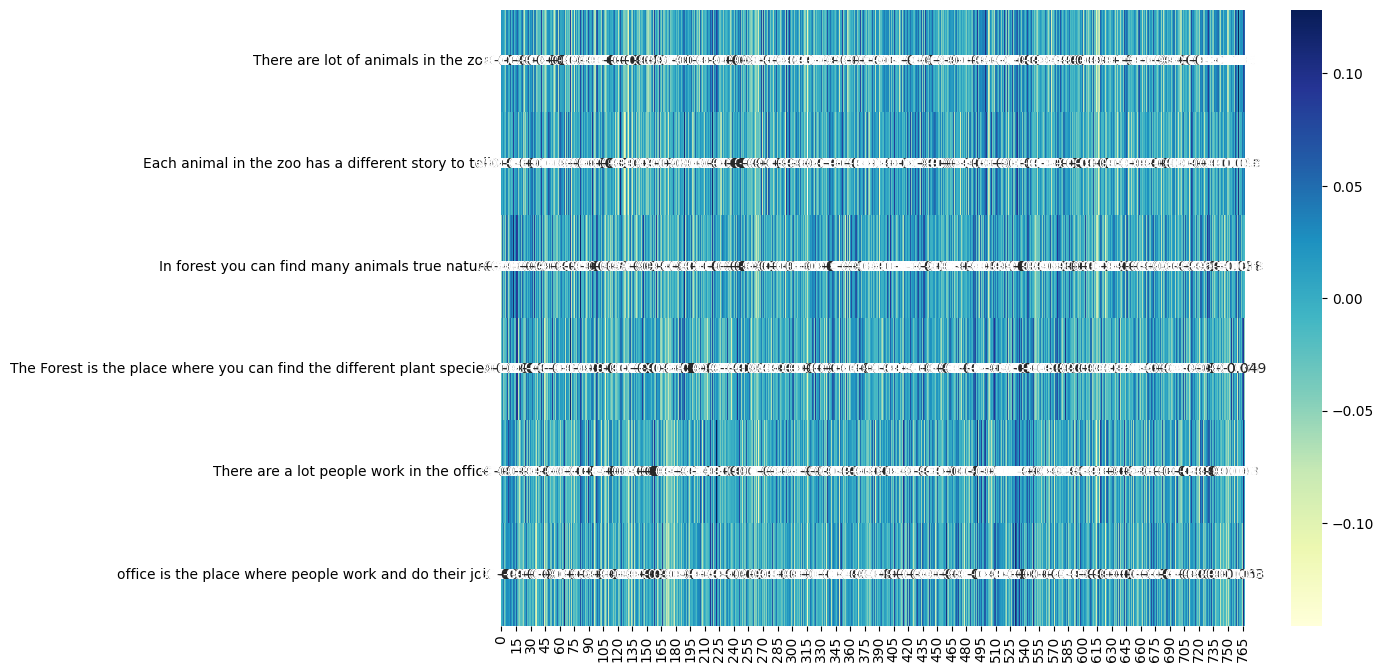

In [71]:
import seaborn as sns
y_labels = sentences
plt.figure(figsize=(12, 8))
sns.heatmap(embeddings_arr, annot=True, cmap="YlGnBu", yticklabels=sentences)
plt.show()

In [75]:
from itertools import combinations

for i, j in combinations(range(len(sentences)), 2):
    sim = cosine_similarity([embeddings_arr[i]], [embeddings_arr[j]])[0][0]
    print(f"Cosine similarity between sent_{i+1} and sent_{j+1}: {sim * 100:.2f}%")

Cosine similarity between sent_1 and sent_2: 71.52%
Cosine similarity between sent_1 and sent_3: 53.64%
Cosine similarity between sent_1 and sent_4: 46.32%
Cosine similarity between sent_1 and sent_5: 59.08%
Cosine similarity between sent_1 and sent_6: 39.20%
Cosine similarity between sent_2 and sent_3: 54.50%
Cosine similarity between sent_2 and sent_4: 45.72%
Cosine similarity between sent_2 and sent_5: 34.38%
Cosine similarity between sent_2 and sent_6: 33.56%
Cosine similarity between sent_3 and sent_4: 64.85%
Cosine similarity between sent_3 and sent_5: 36.41%
Cosine similarity between sent_3 and sent_6: 34.33%
Cosine similarity between sent_4 and sent_5: 36.27%
Cosine similarity between sent_4 and sent_6: 39.24%
Cosine similarity between sent_5 and sent_6: 74.19%


### Application of embedding

In [2]:
import pandas as pd
import numpy as np
question_embeddings = pd.read_csv(r"D:\LLM-Learning-Journey\LLM-Learning-Journey\Week3 - Embedding and vector Database\Data\Stack_overflow_embedding_Question.csv")
so_df = pd.read_csv(r"D:\LLM-Learning-Journey\LLM-Learning-Journey\Week3 - Embedding and vector Database\Data\Stack_overflow_Data.csv")

In [3]:
so_df.head()

,input_text,output_text,category
0,"python's inspect.getfile returns ""<string>""<p>...",<p><code>&lt;string&gt;</code> means that the ...,python
1,Passing parameter to function while multithrea...,<p>Try this and note the difference:</p>\n<pre...,python
2,How do we test a specific method written in a ...,"<p>Duplicate of <a href=""https://stackoverflow...",python
3,how can i remove the black bg color of an imag...,<p>The alpha channel &quot;disappears&quot; be...,python
4,How to extract each sheet within an Excel file...,<p>You need to specify the <code>index</code> ...,python


In [4]:
question_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.035712,-0.002407,0.058603,0.021545,0.036846,-0.024007,0.029984,-0.007032,0.038524,0.023197,...,0.013316,0.035411,0.037812,-0.025224,-0.053827,0.010643,0.023134,-0.031002,-0.008556,-0.019974
1,-0.020243,-0.002625,0.019404,0.028513,0.027673,-0.018409,0.019641,0.016846,-0.002925,0.044673,...,-0.017357,0.074788,0.001394,0.006355,-0.041013,0.040556,0.023180,-0.021581,-0.056554,-0.010405
2,-0.051760,-0.037123,0.026993,-0.003052,-0.022083,0.005886,0.030315,-0.009487,-0.005507,0.077845,...,0.000283,0.038114,0.036886,-0.025383,-0.055989,0.039329,0.024172,-0.070559,-0.040254,0.000921
3,0.022066,-0.028208,0.028496,0.039985,0.031205,-0.005409,0.069121,-0.008138,0.014680,0.022103,...,0.018693,0.042731,-0.015539,-0.022241,-0.046086,0.035012,0.012626,-0.028957,-0.038509,0.012127
4,-0.054981,-0.003241,0.039235,0.001132,0.026566,-0.036894,0.021492,-0.008457,0.020510,0.019507,...,-0.020295,0.026099,-0.037794,0.029497,-0.070101,0.014620,0.047583,-0.047031,-0.050532,-0.007812


#### Clustering

In [5]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [6]:
clustering_dataset = question_embeddings[:1000]

In [7]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, 
                random_state=0, 
                n_init = 'auto').fit(clustering_dataset)

In [8]:
kmeans_labels = kmeans.labels_

In [9]:
PCA_model = PCA(n_components=2)
PCA_model.fit(clustering_dataset)
new_values = PCA_model.transform(clustering_dataset)

In [10]:
import matplotlib.pyplot as plt
import mplcursors

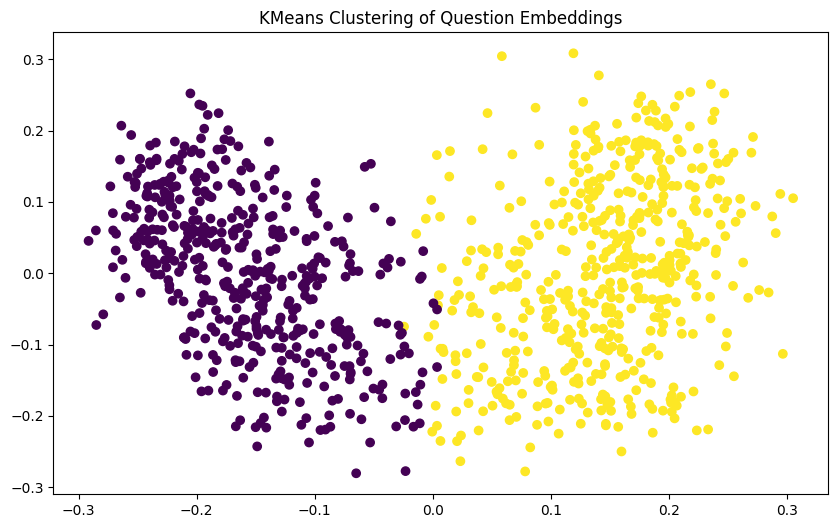

In [11]:
# from utils import clusters_2D
# clusters_2D(x_values = new_values[:,0], y_values = new_values[:,1], 
#             labels = so_df[:1000], kmeans_labels = kmeans_labels)


plt.figure(figsize=(10, 6))
plt.scatter(new_values[:, 0], new_values[:, 1], c=kmeans_labels, cmap='viridis', label=kmeans_labels)
plt.title('KMeans Clustering of Question Embeddings')
plt.show()

#### Classification

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [13]:
X = question_embeddings
X.shape

(2000, 768)

In [14]:
y = so_df['category'].values
y.shape

(2000,)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = 0.2, 
                                                    random_state = 2)

In [16]:
clf = RandomForestClassifier(n_estimators=200)

In [17]:
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) # compute accuracy
print("Accuracy:", accuracy)

Accuracy: 0.68


#### Outlier Detection

In [19]:
from sklearn.ensemble import IsolationForest

In [21]:
clf = IsolationForest(contamination=0.005, 
                      random_state = 2) 

In [22]:
y_pred = clf.fit_predict(question_embeddings)

In [25]:
so_df[y_pred==-1]

,input_text,output_text,category
189,How to install two python versions in one comp...,"<p>For that, you can use <a href=""https://code...",python
254,How can I say to Python to do an instruction a...,<p>You could easy use datetime to help you wit...,python
511,Is there any benefit to writing aria-required=...,"<p>For simplicity, I always leave off the attr...",html
560,How do you get the selected directory path fro...,<p>For security reasons the full path will not...,html
1018,ASP .NET - JSON Serializer not working on clas...,"<p>Ok, I forgot to add default <code>{ get; se...",r
1178,Powershell how to search the file and then ope...,<p>Use <code>Select-Object -First 1</code> to ...,r
1181,Laravel OneToMany query<p>I'm new to Laravel a...,<p>If you want the type and nested in it the m...,r
1220,Alerts on Application Gateway Azure<p>I have t...,<p>Monitoring application gateways is pretty s...,r
1284,How to add a custom RSA key pair to a .pem fil...,"<p>Most major crypto libraries support this, e...",r
1313,Array initialization with ternary operator in ...,"<p>To make your code work, do the following in...",r


In [37]:
so_df.iloc[so_df[y_pred==-1].index].to_numpy()[1]

array(['How can I say to Python to do an instruction at a given time?<p>I want that a specific time of the day (for example 10:00:00), one of my if condition activates.</p>\n<p>For example:</p>\n<p>if time is 10:00:00:\nprint(&quot;Hello world&quot;)</p>\n<p>Imortant: I already read this: <a href="https://stackoverflow.com/questions/15088037/python-script-to-do-something-at-the-same-time-every-day">Python script to do something at the same time every day</a></p>\n<p>But I don\'t want to use a function!</p>',
       '<p>You could easy use datetime to help you with that.</p>\n<pre><code>import datetime\nfrom time import sleep\n\ntiming = [10, 0, 0] # Hour, minute, second, in 24 hour time\n\nwhile True: # Repeat forever\n    now = datetime.datetime.now()\n    data = [now.hour, now.minute, now.second]\n    if data == timing:\n        # Code to be executed\n        print(&quot;Hello World&quot;)\n        #######\n        sleep(1) # To ensure the command is not repeated again\n        # brea

#### Semantic search

In [ ]:
# !pip install faiss-cpu

   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---- ----------------------------------- 2.1/18.9 MB 15.1 MB/s eta 0:00:02
   -------------- ------------------------- 6.8/18.9 MB 19.9 MB/s eta 0:00:01
   --------------------------- ------------ 12.8/18.9 MB 23.0 MB/s eta 0:00:01
   -------------------------------------- - 18.4/18.9 MB 23.8 MB/s eta 0:00:01
   ---------------------------------------- 18.9/18.9 MB 22.2 MB/s  0:00:00


In [ ]:
import faiss
import numpy as np

# your embeddings (convert to float32)
embeddings = np.array(question_embeddings, dtype=np.float32, order='C')

# normalize for cosine similarity (important)
faiss.normalize_L2(embeddings)




In [47]:
dim = embeddings.shape[1]

# Flat index (exact search)
index = faiss.IndexFlatIP(dim)
index.add(embeddings)

In [48]:
query = "How to concatenate two data frames in pandas?"

In [56]:
# -------- QUERY --------
query_embedding = np.array(
    embedding_model.get_embeddings([query])[0].values
).astype("float32").reshape(1, -1)

faiss.normalize_L2(query_embedding)

# search
D, I = index.search(query_embedding, k=1)

neighbors = I[0]
distances = D[0]

print(neighbors, distances)

[1461] [0.08114077]


In [68]:
so_df.iloc[neighbors[0].item()]['input_text']

"THREE.js revolving smoke effect works only for one element instead of applying to all elements<p>I am trying to create a custom post header background for a forum website. But because I always want to make my life more difficult I tried to make it fancy. I also need to link to that script in every post.</p>\n<p>When I duplicate the post (or simulate it by just ctrl+a ctrl+c ctrl+v ctrl+v the HTMP code) only the last post gets any smoke effect background. I tried to add the function to the window on init and loop it for every element with the SiffrinSmoke class but still only one smoke is displayed - at the bottom.</p>\n<p>HTML:</p>\n<pre><code>&lt;div class=&quot;SiffrinBody&quot;&gt;\n    &lt;div class=&quot;SiffrinHeader&quot;&gt;\n        &lt;div class=&quot;SiffrinSmoke&quot;&gt;\n            &lt;!--h1&gt;Siffrin&lt;br&gt;Drauglir&lt;/h1--&gt;\n            &lt;h1 data-heading=&quot;Siffrin&amp;#xa;Drauglir&quot;&gt;&lt;/h1&gt;\n        &lt;/div&gt;\n        &lt;div class=&quot;Sif